# Optical nerve analysis from segmentation

## Setup

### Import libraries:

In [2]:
import sys
sys.path.append('/home/jovyan/projects/cellcount/')
import os
print(os.getcwd())
os.chdir('/home/jovyan/projects/cellcount')
print(os.getcwd())
import pandas as pd
import numpy as np
#import scipy as sc
import seaborn as sns
import matplotlib.pyplot as plt
#from matplotlib.image import NonUniformImage
import matplotlib.gridspec as gridspec
#import matplotlib.image as mpimg
%matplotlib inline
from skimage import io
#from skimage import measure
#from skimage import color
from PIL import Image
# from pathlib import Path
# from read_roi import read_roi_zip
# from shapely.geometry import Polygon, MultiPolygon, GeometryCollection
# from shapely.validation import explain_validity, make_valid
from utils import *

from pickle import dump, load

/home/jovyan/projects/cellcount
/home/jovyan/projects/cellcount


### Choose parameters:

In [4]:
## Set species here:
species = 'Du25'

save_final_data = False

### Defines environment variables:

In [7]:
SPECIES_NAMES = {
    'Hr11': 'Barn Swallow \n(Hr11)',
    'Hr21': 'Barn Swallow \n(Hr21)',
    'Cj22': 'Japanese Quail \n(Cj22)',
    'Aa14': 'Common Swift \n(Aa14)',
    'Du26': 'House Martin \n(Du26)',
    'Du25': 'House Martin \n(Du25)',
    'Mc12': 'Grey Wagtail \n(Mc12)',
    'Ft10': 'Common Kestrel \n(Ft10)',
    'Fp23': 'Peregrine Falcon \n(Fp23)'
}

COLORS = {
    'Hr11': "#1E72FA",
    'Hr21': "#1E72FA",
    'Aa14': "#E01EFA",
    'Du25': "#0145B3",
    'Du26': "#0145B3",
    'Ft10': "#1ED9FA",
    'Fp23': "#11A0AA",
    #'Mm04': "#B87B2B",
    'Mc12': "#975408",
    #'An01': "#E47900",
    'Cj22': "#37FF0F",
    'all':  "#000000"
}

# microns/pixel ratio from in the optic nerve (ON) image:
# the ratio is about the same for all species: microns/pixel ratio =~ 0.1 
# except for Aa14 where it is =~0.07
PX_RATIOS = {
    'Aa06': 1216.66/12285,
    'Aa14': 1228.76/18684, # different resolution
    'Cj22': 1671.23/16875,
    'Cl': 1588.34/16038,
    'Du26': 847.35/8556,
    'Du25': 1026.80/10368,
    'Fp23': 2510.86/25353,
    'Ft10': 1949.32/19683,
    'Hr11': 1032.15/10422,
    'Hr21': 1120.39/11313,
    'Mc12': 1112.37/11232,
}
# for s, r in PX_RATIOS.items():
#     print(s, r)

ON_FOLDER_NAME = {
    'Aa06': "ON1_1/Aa06 - ON1_1 6_3",
    'Aa14': "ON1_1",
    'Cj22': "ON1_1",
    'Cl': "Cl_PV_ON",
    'Du26': "ON1_1",
    'Du25': "Du25_ON2",
    'Fp23': "ON2",
    'Ft10': "ON1_1",
    'Hr11': "ON1_1",
    'Hr21': "ON1_1",
    'Mc12': "ON1_1",   
}

ON_IMAGE_FILENAMES = {
    'Aa06': "Aa06 - ON1_1 6_3 - 2 - 63x-Stitching-02.czi - Aa06 - ON1_1 6_3 - 2 - 63x-Stitching-02.czi #1.tif",
    'Aa14': "Aa14_ON2_4_4-1-63x-Stitching-05.czi - Aa14_ON2_4_4-1-63x-Stitching-05.czi #1.tif",
    'Cj22': "Cj22_ON1_5-1_1-63x-Stitching-05.czi - Cj22_ON1_5-1_1-63x-Stitching-05.czi #1.tif",
    'Cl': "ClCl PV 10W ON 3_3 - 1 - 63x overview-Stitching-01.czi #1.tif",
    'Du26': "Du26_ON1_6bis_1-63x_2-Stitching-02.czi - Du26_ON1_6bis_1-63x_2-Stitching-02.czi #1.tif",
    'Du25': "Du25_ON2_6-Stitching-02.czi - Du25_ON2_6-Stitching-02.czi #1_crop.tif",
    'Fp23': "Fp23_ON2_7-3-63x-Stitching-01.czi - Fp23_ON2_7-3-63x-Stitching-01.czi #1.tif",
    'Ft10': "Ft10_ON1_9-Stitching-01.czi - Ft10_ON1_9-Stitching-01.czi #1_crop.tif",
    'Hr11': "Hr11 - ON1_1 6_4 - 2 - 63x overview-Stitching-04.tif",
    'Hr21': "Hr21_ON2_5-4_1-63x-Stitching-03.czi - Hr21_ON2_5-4_1-63x-Stitching-03.czi #1.tif",
    'Mc12': "Mc12_ON2_7bis_2-63x-Stitching-03.czi - Mc12_ON2_7bis_2-63x-Stitching-03.czi #1.tif"
}

### Define paths :

In [9]:
path2kdrive = "/home/jovyan/kDrive"
path2data = os.path.join(path2kdrive, "cellcount/data/onunet/optical_nerve")
path2rawimages = os.path.join(path2kdrive, "cellcount/data/BVSA-Histology-Epoxy")
print("main path to predicted data:", path2data)

foldername = ON_FOLDER_NAME[species]
imagefilename = ON_IMAGE_FILENAMES[species]
path2image = os.path.join(path2rawimages, species, foldername, imagefilename)
print(f"path to raw image: {path2image}")

path2test = os.path.join(path2data, "test")
pickle_filename = f"pickled_data/cellmarks_{species}.pickle"
archive_label = None
#archive_label = '03_10_2023'
if archive_label is None:
    path2prediction = os.path.join(path2data, "prediction", species)
else:
    path2prediction = os.path.join(path2data, "prediction_archive", archive_label, species)

print("using following prediction:", path2prediction)

main path to predicted data: /home/jovyan/kDrive/cellcount/data/onunet/optical_nerve
path to raw image: /home/jovyan/kDrive/cellcount/data/BVSA-Histology-Epoxy/Du25/Du25_ON2/Du25_ON2_6-Stitching-02.czi - Du25_ON2_6-Stitching-02.czi #1_crop.tif
using following prediction: /home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/prediction/Du25


In [ ]:

# path to whole optical nerve image for 'species':
#path2dir = os.path.join("data/BVSA-Histology-Epoxy", species, "ON1_1")
# if species == 'Aa06':
#     imagefilename = "Aa06 - ON1_1 6_3 - 2 - 63x-Stitching-02.czi - Aa06 - ON1_1 6_3 - 2 - 63x-Stitching-02.czi #1.tif"
#     foldername = os.path.join("ON1_1", "Aa06 - ON1_1 6_3")
#     path2dir = os.path.join(path2rawimages, species, foldername)
#     #px_ratio = 1216.66/12285
# elif species == 'Hr11':
#     imagefilename = "Hr11 - ON1_1 6_4 - 2 - 63x overview-Stitching-04.tif"
#     foldername = "ON1_1"
#     #px_ratio = 1032.15/10422
#     # path2dir = os.path.join("tania/Bird_Visual_System_Atlas/BVSA-Histology-Epoxy", species, foldername) # old path
#     path2dir = os.path.join(path2rawimages, species, foldername)
# elif species == 'Mc12':
#     imagefilename = "Mc12_ON2_7bis_2-63x-Stitching-03.czi - Mc12_ON2_7bis_2-63x-Stitching-03.czi #1.tif"
#     foldername = "ON1_1"
#     #px_ratio = 1112.37/11232
#     path2dir = os.path.join(path2rawimages, species, foldername)
#     #imagefilename = "Mc12-ON1_w 6_3-1-63x_overview-Stitching-01.czi_#1.tif" ## previous sample
#     #foldername = "Mc12-ON1_w 6_3"
#     #path2dir = os.path.join("tania/Bird_Visual_System_Atlas/BVSA-Histology-Epoxy", species, foldername)
# elif species == 'Cl': # data stored under a completely different path
#     imagefilename = "ClCl PV 10W ON 3_3 - 1 - 63x overview-Stitching-01.czi #1.tif"
#     foldername = "Cl PV ON"
#     #px_ratio = 1588.34/16038
#     path2dir = os.path.join("tania/Epoxy_Histology/Pigeon", foldername)
# elif species == 'Aa14': 
#     imagefilename = "Aa14_ON2_4_4-1-63x-Stitching-05.czi - Aa14_ON2_4_4-1-63x-Stitching-05.czi #1.tif"
#     foldername = "ON1_1"
#     path2dir = os.path.join(path2rawimages, species, foldername)
#     #px_ratio = 1228.76/18684
# elif species == 'Hr21': 
#     imagefilename = "Hr21_ON2_5-4_1-63x-Stitching-03.czi - Hr21_ON2_5-4_1-63x-Stitching-03.czi #1.tif"
#     foldername = "ON1_1"
#     path2dir = os.path.join(path2rawimages, species, foldername)
#     #PX_RATIOS[species] = 1120.39/11313
# elif species == 'Cj22': 
#     imagefilename = "Cj22_ON1_5-1_1-63x-Stitching-05.czi - Cj22_ON1_5-1_1-63x-Stitching-05.czi #1.tif"
#     foldername = "ON1_1"
#     path2dir = os.path.join(path2rawimages, species, foldername)
#     #px_ratio = 1671.23/16875
# elif species == 'Du26': 
#     imagefilename = "Du26_ON1_6bis_1-63x_2-Stitching-02.czi - Du26_ON1_6bis_1-63x_2-Stitching-02.czi #1.tif"
#     foldername = "ON1_1"
#     path2dir = os.path.join(path2rawimages, species, foldername)
#     #px_ratio = 847.35/8556
# elif species == 'Fp23': 
#     imagefilename = "Fp23_ON2_7-3-63x-Stitching-01.czi - Fp23_ON2_7-3-63x-Stitching-01.czi #1.tif"
#     foldername = "ON2"
#     path2dir = os.path.join(path2rawimages, species, foldername)
#     #px_ratio = 2510.86/25353
# elif species == 'Ft10': 
#     imagefilename = "Ft10_ON1_9-Stitching-01.czi - Ft10_ON1_9-Stitching-01.czi #1_crop.tif"
#     foldername = "ON1_1"
#     path2dir = os.path.join(path2rawimages, species, foldername)
#     #px_ratio = 1949.32/19683
# elif species == 'Du25': 
#     imagefilename = "Du25_ON2_6-Stitching-02.czi - Du25_ON2_6-Stitching-02.czi #1_crop.tif"
#     foldername = "Du25_ON2"
#     path2dir = os.path.join(path2rawimages, species, foldername)
#     #px_ratio = 1026.80/10368
# else:
#     raise ValueError('Unknown species or data not available for this species !')

# open file with whole optical nerve image:
#path2image = os.path.join(path2kdrive, path2dir, imagefilename)


/home/jovyan/kDrive/cellcount/data/BVSA-Histology-Epoxy/Ft10/ON1_1/Ft10_ON1_9-Stitching-01.czi - Ft10_ON1_9-Stitching-01.czi #1_crop.tif


## Test: plot prediction vs label

In [11]:
def add_grid(ax, grid_ticks):
    for i in grid_ticks:
        ax.axvline(x=i, ymin=0, ymax=512, linestyle='dashed')
        ax.axhline(y=i, xmin=0, xmax=512, linestyle='dashed')

# def add_scale(ax, length):
#     #ax.axhline(y=480, xmin=50, xmax=50 + length, linewidth=2)
#     ax.axhline(y=480, xmin=50, xmax=100, linewidth=2)

In [12]:
def plot_prediction_vs_label(path2directory, i, j, subdirectory=None, path2save=None):
    if subdirectory is None:
        path2prediction = path2directory
    else:
        path2prediction = os.path.join(path2directory, subdirectory)

    # load original tile as well as predicted mask
    tile = import_tile_asarray(path2directory, i, j, show_tile=False) / 255.
    label = import_label_asarray(path2directory, i, j, show_label=False) / 255.    
    pred = import_pred_asarray(path2prediction, i, j, show_pred=False) / 255.

    fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(30,10))
    grid_ticks = [100, 200, 300, 400, 500]
    ax1.imshow(label, cmap=plt.cm.gray)
    #add_scale(ax1, 50)
    add_grid(ax1, grid_ticks)
    ax1.set_title('hand label')
    ax2.imshow(tile, cmap=plt.cm.gray)
    add_grid(ax2, grid_ticks)
    ax2.set_title('original image (100px = 10$\mu$m)')
    ax3.imshow(pred, cmap=plt.cm.gray)
    add_grid(ax3, grid_ticks)
    ax3.set_title('predicted mask')

    fig.suptitle(f"Manual vs algorithmic segmentation for the tile ({i}, {j})", fontsize=20)

In [13]:
plot_prediction_vs_label(path2test, i=8, j=3, subdirectory="pred_on_weights_from_scratch_9examples")

FileNotFoundError: No such file: '/home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/test/tile_8_3.png'

## Test some postprocessing

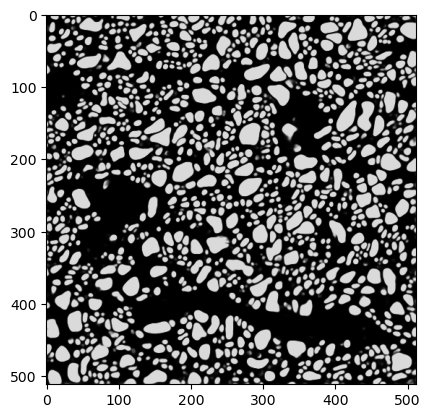

In [10]:
# read-in a given predicted tile:
i=8
j=9
path2tile_in = os.path.join(path2data, 'prediction', species, 'tiles')
path2tile_out = os.path.join(path2data, 'prediction_postprocessed', species, "predict_" + str(i) + "_" + str(j) + ".png")
pred = import_pred_asarray(path2tile_in, i, j, show_pred=True) #/ 255.

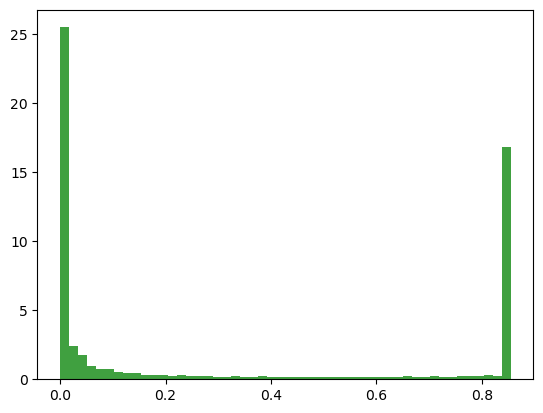

In [11]:
n, bins, patches = plt.hist(pred.flatten()/ 255., 50, density=True, facecolor='g', alpha=0.75)

In [12]:
## Do some postprocessing here...
#pred_pp = pred
# making a binary mask from the prediction:
thr = 165
#thr = 0.5
# pred_pp = np.zeros(pred.shape)
# pred_pp[pred > thr] = 255
# pred_pp[pred <= thr] = 0
pred_pp = np.where(pred > thr, 255, 0)

In [13]:
# save post-processed tile
img = Image.fromarray(pred_pp.astype(np.uint8))
img.save(path2tile_out)

## Cellmarks from prediction

### Segmentation on entire ON section:

In [6]:
# for testing:
Image.MAX_IMAGE_PIXELS = None # avoid the "DOS decompression bomb warning/error" by unlimiting the size of the displayed image
print(path2prediction)
mask = io.imread(os.path.join(path2prediction, 'predicted_raw_mask.png'))
mask_array = np.array(mask) / 255.

/home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/prediction/Hr11


In [7]:
path2prediction

'/home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/prediction/Hr11'

In [8]:
Image.MAX_IMAGE_PIXELS = None # avoid the "DOS decompression bomb warning/error" by unlimiting the size of the displayed image
highlight_threshold = 10 # highlights in red axons with area greater than this value (micrometers^2)
#cellmarks_whole, df_axons = cellmarks_from_whole_mask(
cellmarks_whole = cellmarks_from_whole_mask(
    os.path.join(path2prediction, 'predicted_raw_mask.png'),
    path2image,
    contour_thr=0.7,
    discard_thr=0.1,
    highlight_thr=highlight_threshold, # Hr21: 12.944474, Aa14: 7.365529; used only on original image
    show_largest_only=True,
    #path2save_cellmarks=os.path.join(path2prediction, 'predicted_cellmarks_larger_than_15.png'),
    #path2save_cellmarks=os.path.join(path2prediction, 'predicted_cellmarks.png'),
    #path2save_biggest_only=os.path.join(path2prediction, f"largest_axons_on_mask_thr_{highlight_threshold}.png"),
    path2save_highlight_axons=os.path.join(path2prediction, f"largest_axons_on_mask_highlighted"),
    binary=True,
    binary_thr=0.7,
    #path2save_binary_mask=os.path.join(path2prediction, 'predicted_binary_mask.png'),
    px_ratio=PX_RATIOS[species]
)

(12231, 10422)
(11492, 10331)
Number of detected cellmarks: 257739


In [ ]:
# Saved data for further use:
with open(pickle_filename, 'bw') as f:
    dump(cellmarks_whole, f)

## Load previously saved cellmarks

In [14]:
with open(pickle_filename, 'rb') as f:
    cellmarks_whole = load(f)

In [15]:
# convert cellmark coordinates into shapely polygons:
polygons = [contour2polygon(i) for i in cellmarks_whole]
# get centroids (in pixel coordinates) of each polygon, and its x-coordinate:
centroids = [polygons[i].centroid for i in range(len(polygons))]
centroids_x = [i.coords[0][0] for i in centroids]
centroids_y = [i.coords[0][1] for i in centroids]
# compute area, in microns, of each polygon:
areas = [polygons[i].area * PX_RATIOS[species] ** 2 for i in range(len(polygons))]
df_axons = pd.DataFrame({'x': centroids_x, 'y': centroids_y, 'area': areas})
df_axons.sort_values(by='area', ascending=False, inplace=True)
df_axons.head(n=10)

,x,y,area
542965,16292.601897,13477.389833,41.183903
425587,12827.131409,9164.724027,38.418026
347234,10766.891847,10525.795776,34.098551
430329,12969.574649,16839.118167,34.047549
432810,13030.644440,9009.225356,33.961238
41259,2778.092254,6903.734346,33.659149
487535,14687.259479,7927.275394,31.248325
523682,15706.138729,7890.532478,30.875618
427044,12859.245497,9106.302218,30.104703
540255,16208.682126,12850.616265,29.545643


In [16]:
len(df_axons)

627775

In [17]:
df_biggest_axons = df_axons[df_axons['area'] >= 10]
len(df_biggest_axons)

1864

## Prepare an axon area heatmap:

In [34]:
# load original image as well as predicted mask
from PIL import Image # unable to display the Cl image
Image.MAX_IMAGE_PIXELS = None # avoid the "DOS decompression bomb warning/error"
img = io.imread(path2image)
print(img.shape)
raw_mask = io.imread(os.path.join(path2prediction, 'predicted_raw_mask.png'))

(20655, 19683)


In [35]:
bin_width = 50 # bin width in microns:
area_thr = 5 # area in micrometers^2
reject_thr = 0.09 # area minimal threshold in micrometer^2
axon_total_nb = 0
rejected_cellmarks = 0
x_min = 0
x_max = img.shape[0]
y_min = 0
y_max = img.shape[1]
# x_min = np.min(centroids_x)
# x_max = np.max(centroids_x)
# y_min = np.min(centroids_y)
# y_max = np.max(centroids_y)
print(x_min, x_max)
print(y_min, y_max)
x_nbins = round((x_max - x_min) * PX_RATIOS[species] / bin_width)
y_nbins = round((y_max - y_min) * PX_RATIOS[species] / bin_width)
print(f"Number of bins vertically: {x_nbins}, and horizontally: {y_nbins}")
x_edges = np.linspace(round(x_min)-1, round(x_max)+1, x_nbins + 1) # vertically
y_edges = np.linspace(round(y_min)-1, round(y_max)+1, y_nbins + 1) # horizontally
counts = np.zeros((x_nbins, y_nbins))
counts_large = np.zeros((x_nbins, y_nbins))

for idx, row in df_axons.iterrows():
    i = np.sum(x_edges < row.x) - 1
    j = np.sum(y_edges < row.y) - 1
    if row.area >= area_thr:
        counts_large[i,j] = counts_large[i,j] + 1
        axon_total_nb += 1
    elif row.area >= reject_thr: # rejecting smaller cellmarks as probably not axons
        counts[i,j] = counts[i,j] + 1
        axon_total_nb += 1
    else:
        rejected_cellmarks += 1

print(f"Total number of axons: {axon_total_nb}")
print(f"Number of rejected cellmarks (with area smaller than {reject_thr}): {rejected_cellmarks}")

0 20655
0 19683
Number of bins vertically: 41, and horizontally: 39
Total number of axons: 627775
Number of rejected cellmarks (with area smaller than 0.09): 0


In [ ]:
## Optionnally rotate image 90° clockwise:
# raw_mask = np.rot90(raw_mask, k=3)
# counts = np.rot90(counts, k=3)
# counts_large = np.rot90(counts_large, k=3)

In [41]:
# Y_AXIS_LIMITS = { # in pixels
#     #'Hr11': [0, 1.2e4],
#     'Hr11': [0, raw_mask.shape[0]],
#     'Hr21': [0, 9e3],
#     'Mc12': [0, 1.5e4],
#     'Du26': [0, 8e3],
#     'Du25': [0, 9e3],
#     'Aa14': [0, 1.6e4],
#     'Cj22': [0, 1.6e4],
#     'Ft10': [0, 2.2e4],
# }

# X_AXIS_LIMITS = { # in pixels
#     #'Hr11': [0, 1e4],
#     'Hr11': [0, raw_mask.shape[1]],
#     'Hr21': [0, 1.2e4],
#     'Mc12': [0, 1.2e4],
#     'Du26': [0, 9e3],
#     'Du25': [0, 1e4],
#     'Aa14': [0, 1.8e4],
#     'Cj22': [0, 1.8e4],
#     'Ft10': [0, 2e4],
# }

SPECIES_TITLE_ANCHOR = {
    'Hr11': -0.02,
    'Aa14': -0.03,
    'Du26': -0.04,
    'Mc12': -0.02,
    'Ft10': -0.04,
    'Cj22':-0.04,
    'Fp23': -0.04,
}

BINARY_IMG_LABEL_STEP = {
    'Hr11': 2.5e2,
    'Aa14': 2.5e2,
    'Du26': 2.5e2,
    'Mc12': 2.5e2,
    'Ft10': 5e2,
    'Cj22': 2.5e2,
    'Fp23': 5e2,
}

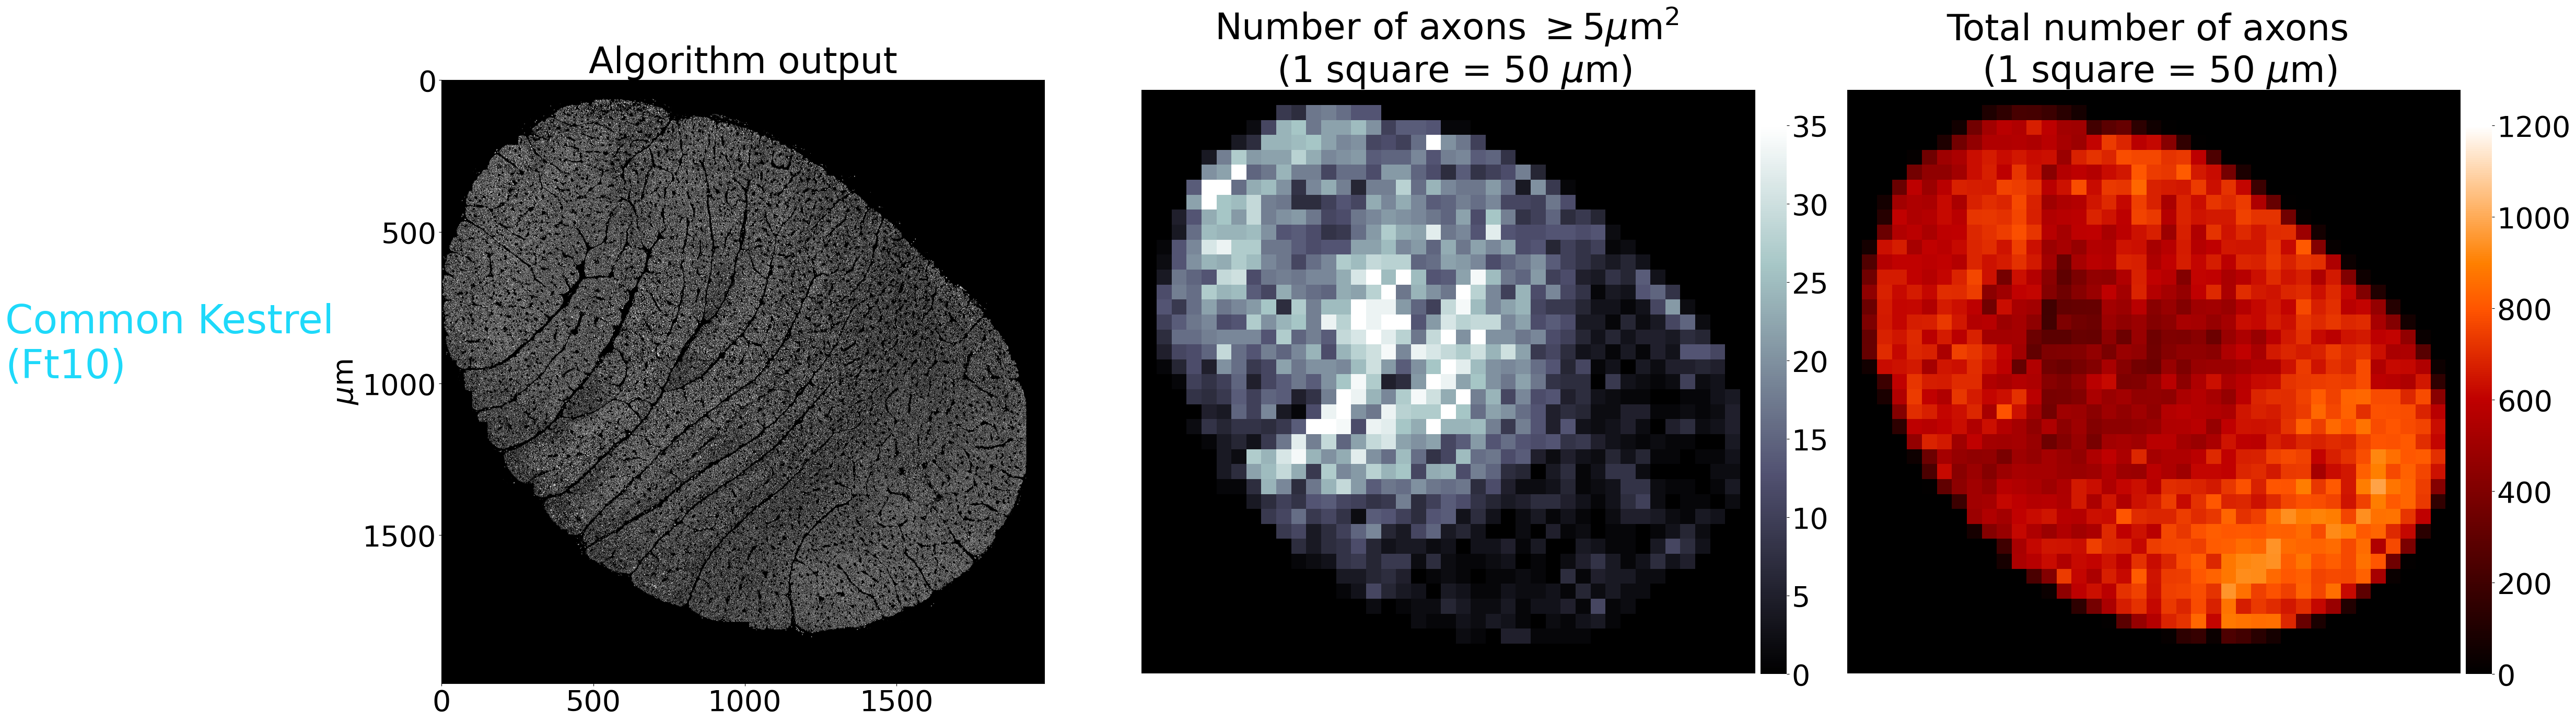

In [46]:
PLOT_ORIGINAL_IMAGE = False
SHOW_CBAR = True
if PLOT_ORIGINAL_IMAGE:
    fig, (ax0, ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=4, figsize=(50,15)) # with original image
else:
    #fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(50,15)) # without original image
    fig = plt.figure(figsize=(50, 15))
    spec = gridspec.GridSpec(ncols=3, nrows=1, wspace=0.15, hspace=0.15)

if PLOT_ORIGINAL_IMAGE:
    ax0.imshow(img, cmap=plt.cm.gray)
    ax0.set_title('Original image ($10$px$\simeq 1\mu$m)', fontsize=18)


ax1 = fig.add_subplot(spec[0])
ax1.imshow(raw_mask, cmap='gray', origin='upper', vmin=0, vmax=255, aspect='equal')

#ax1.set_aspect('equal')

# Keep the image orientation (origin at upper-left):
ax1.invert_yaxis()  # This ensures y=0 is at the top

# define x-axis limits, ticks and labels:
x_axis_limits = [0, raw_mask.shape[1]] #X_AXIS_LIMITS[species] # in pixels
x_label_step = BINARY_IMG_LABEL_STEP[species] #2.5e2 # X_LABEL_STEP[species] # in microns
x_ticks = np.arange(x_axis_limits[0], x_axis_limits[1], x_label_step/PX_RATIOS[species]) # ticks locations are in pixels
x_labels = [t*x_label_step for t in range(len(x_ticks))] # ticks labels are in microns
# define y-axis limits, ticks and labels:
y_axis_limits = [0, raw_mask.shape[0]] #Y_AXIS_LIMITS[species] # in pixels
y_label_step = BINARY_IMG_LABEL_STEP[species] #2.5e2 #Y_LABEL_STEP[species] # in microns
y_ticks = np.arange(y_axis_limits[0], y_axis_limits[1], y_label_step/PX_RATIOS[species])
y_labels = [t*y_label_step for t in range(len(y_ticks))] # ticks labels are in microns

# print(x_axis_limits)
# print(x_ticks)
# print(x_labels)
# print(y_axis_limits)
# print(y_ticks)
# print(y_labels)

if SHOW_CBAR:
    ax1.set_title('Algorithm output', fontsize=50)
    ax1.set_xlim(x_axis_limits[0], x_axis_limits[1])
    ax1.set_xticks(x_ticks)
    ax1.set_xticklabels([int(x) for x in x_labels], fontsize=40)
else: 
    ax1.set_xticks([])
    ax1.set_xticklabels([])


ax1.set_ylim(y_axis_limits[1], y_axis_limits[0]) # Note: reversed order for inverted axis
ax1.set_yticks(y_ticks)
ax1.set_yticklabels([int(x) for x in y_labels], fontsize=40)
ax1.set_ylabel("$\mu$m", fontsize=40)

# Modify tick labels to show the scale on microns instead of pixels:
# x_ticks = ax1.get_xticks()
# y_ticks = ax1.get_yticks()
# print(f"Pixel ratio for {species} is {PX_RATIOS[species]} microns/pixels")
# print(f"Image dimension for {species} is {raw_mask.shape}")
# ax1.set_xticklabels([int(tick * px_ratio) for tick in x_ticks])
# ax1.set_yticklabels([int(tick * px_ratio) for tick in y_ticks])

# Modify tick label font sizes individually
# for label in ax1.get_xticklabels():
#     label.set_fontsize(30)
# for label in ax1.get_yticklabels():
#     label.set_fontsize(30)
#ax1.set_xticks(fontsize=14)
# yticks_locations = np.arange(0, 8e3, 1e3)
# ax1.set_yticks(yticks_locations)
#ax1.set_yticklabels(list(SPECIES_NAMES.values()) + ["all"], fontsize=11)

ax2 = fig.add_subplot(spec[1])
if SHOW_CBAR:
    # Create a separate axes for the colorbar
    cbar_ax2 = fig.add_axes([0.632, 0.122, 0.01, 0.7])  # [left, bottom, width, height] FOR Fp23
    #cbar_ax2 = fig.add_axes([0.632, 0.135, 0.01, 0.7])  # [left, bottom, width, height] FOR Fp23
    #cbar_ax2 = fig.add_axes([0.615, 0.11, 0.01, 0.7])  # [left, bottom, width, height] FOR Hr11

hm_counts_large = sns.heatmap(
    counts_large,
    vmin=0,
    vmax=35,
    cmap="bone",
    xticklabels=False,
    yticklabels=False,
    ax=ax2,
    square=True,
    cbar=SHOW_CBAR,
    cbar_ax=cbar_ax2 if SHOW_CBAR else None,
    cbar_kws={'shrink': 0.8}
)

if SHOW_CBAR:
    ax2.set_title('Number of axons $\geq$' + str(area_thr) + '$\mu$m$^2$ \n (1 square = ' + str(bin_width) + ' $\mu$m)', fontsize=50)
    cbar = hm_counts_large.collections[0].colorbar
    cbar.ax.tick_params(labelsize=40)

ax3 = fig.add_subplot(spec[2])
if SHOW_CBAR:
    # Create a separate axes for the second colorbar
    cbar_ax3 = fig.add_axes([0.902, 0.122, 0.01, 0.7])  # [left, bottom, width, height] FOR Ft10
    #cbar_ax3 = fig.add_axes([0.902, 0.135, 0.01, 0.7])  # [left, bottom, width, height] FOR Fp23
    #cbar_ax3 = fig.add_axes([0.8815, 0.135, 0.01, 0.7])  # [left, bottom, width, height] FOR Hr11
    
hm_counts = sns.heatmap(
    counts,
    vmin=0,
    vmax=1200,
    cmap="gist_heat",
    xticklabels=False,
    yticklabels=False,
    ax=ax3,
    square=True,
    cbar=SHOW_CBAR,
    cbar_ax=cbar_ax3 if SHOW_CBAR else None,
    cbar_kws={'shrink': 0.6}
)

if SHOW_CBAR:
    ax3.set_title('Total number of axons \n (1 square = ' + str(bin_width) + ' $\mu$m)', fontsize=50)
    cbar = hm_counts.collections[0].colorbar
    cbar.ax.tick_params(labelsize=40)


plt.gcf().text(SPECIES_TITLE_ANCHOR[species], 0.5, SPECIES_NAMES[species], color=COLORS[species], fontsize=55)
#fig.suptitle(f"Axon densities in the optic nerve for {species}", fontsize=35)
fig.savefig(os.path.join(path2prediction, f"axons_density_map_{species}_rotated.png"), facecolor='white', bbox_inches='tight')

## Axon sizes distribution

In [32]:
cellmarks_dict = {}
for s in [species]:
    pickle_filename = f"pickled_data/cellmarks_{s}.pickle"
    with open(pickle_filename, 'rb') as f:
        cellmarks_dict[s] = load(f)

print(cellmarks_dict.keys())

dict_keys(['Fp23'])


In [33]:
area_dict = get_axon_area(cellmarks_dict, ratios_dict={species: PX_RATIOS[species]})

Fp23


will be saved in: /home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/prediction/Fp23/axon_sizes_distribution.png
Largest axon is : 39.216637135920756 $\mu$m$^2$


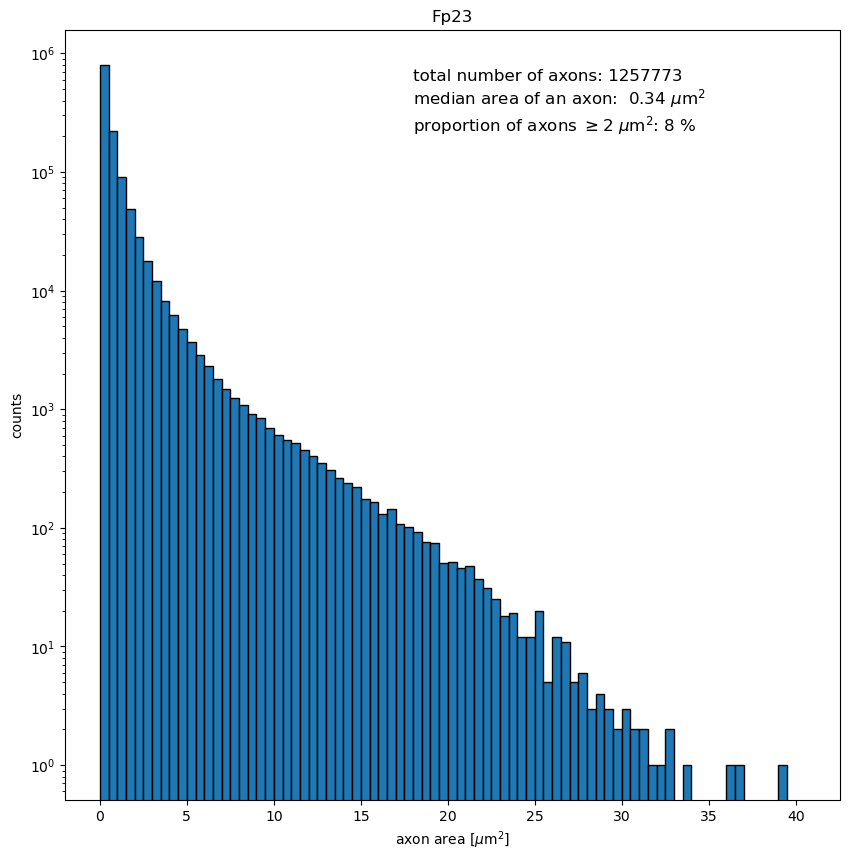

In [34]:
path2save = os.path.join(path2prediction, 'axon_sizes_distribution.png')
print('will be saved in:', path2save)
h = axons_sizes_distribution(
    area_dict,
    area_thr=2,
    path2save=path2save
)